# Music and Mental Health - Exploratory Data Analysis (EDA)

## Importing Packages

In [235]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [236]:
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(sns.__version__)

2.4.2
3.0.1
3.10.8
0.13.2


## Loading Dataset

In [237]:
df = pd.read_csv("../data/mxmh_survey_results.csv")

In [238]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


## Inspection of Dataset

* Dataset Creator
> Catherine Rasgaitis

* Dataset Souce
> Kaggle

*  Attributes of a dataset:
  * 'Timestamp'
  * 'Age'
  * 'Primary streaming service'
  * 'Hours per day',
  * 'While working'
  * 'Instrumentalist'
  * 'Composer'
  * 'Fav genre'
  * 'Exploratory'
  * 'Foreign languages'
  * 'BPM'
  * 'Frequency [Classical]'
  * 'Frequency [Country]'
  * 'Frequency [EDM]'
  * 'Frequency [Folk]'
  * 'Frequency [Gospel]'
  * 'Frequency [Hip hop]'
  * 'Frequency [Jazz]'
  * 'Frequency [K pop]'
  * 'Frequency [Latin]'
  * 'Frequency [Lofi]'
  * 'Frequency [Metal]'
  * 'Frequency [Pop]'
  * 'Frequency [R&B]'
  * 'Frequency [Rap]'
  * 'Frequency [Rock]'
  * 'Frequency [Video game music]'
  * 'Anxiety'
  * 'Depression'
  * 'Insomnia'
  * 'OCD'
  * 'Music effects'
  * 'Permissions'

  **Dataset Objective:**

  > In current context of the world, constant work pressure and mental stress, music therapy has been used for dealing with mental health of people. I has shown positive results in elevating the mood of individuals.

  > The dataset is used for indentifying any relationship or correlation between individual's music taste and their mental health

  > With the help of this dataset or survey, music therapy can be utilized for effectively for acquiring better results in mental health of individuals

  **Dataset Status:**

  > There is total 24288 elements in the dataset

  > The total number of rows and columns in the dataset is 33 and 736 respectively

  > Total size or memory size of the dataset is 189.9 KB

In [239]:
print("Total Number of Elements in the dataset:", df.size)
print("Number of rows and columns in the dataset (rows, columns):", df.shape)
print("Details of the Dataset:")
df.info(verbose = False)

Total Number of Elements in the dataset: 24288
Number of rows and columns in the dataset (rows, columns): (736, 33)
Details of the Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Columns: 33 entries, Timestamp to Permissions
dtypes: float64(7), str(26)
memory usage: 189.9 KB


In [240]:
df.isna().sum().sum() # total missing values check in the dataframe

np.int64(129)

**Data Types of Columns**
- The dataset columns contain numeric values, character

**Missing Values in the Dataset**
- The dataset column contains missing values due to uncertainity of the question for individuals during the survey and some questions with greater difficulty like Beats Per Minute (BPM) were kept optional.

## Data Cleaning

### Searching for Missing Values and Duplicate Columns

In [241]:
df.isna().sum() 
# df.isnull().sum # same as isna (isnull is a older function and isna was introduced in the latter version of pd for matching the naming convention with numpy's NaN)

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

In [242]:
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicated Columns:", df.T.duplicated().sum())

# df.drop_duplicates() # used for dropping the duplicated rows

Duplicate Rows: 0
Duplicated Columns: 0


### Cleaning the Numerical Columns using Data imputation Techniques (mean, median)

In [243]:
# all 3 ways produce the same output
df.select_dtypes(include='number').head()

# df.select_dtypes(include=np.number)
# df.select_dtypes(['number'])

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
0,18.0,3.0,156.0,3.0,0.0,1.0,0.0
1,63.0,1.5,119.0,7.0,2.0,2.0,1.0
2,18.0,4.0,132.0,7.0,7.0,10.0,2.0
3,61.0,2.5,84.0,9.0,7.0,3.0,3.0
4,18.0,4.0,107.0,7.0,2.0,5.0,9.0


In [244]:
df.select_dtypes(include = 'number').isna().sum()

Age                1
Hours per day      0
BPM              107
Anxiety            0
Depression         0
Insomnia           0
OCD                0
dtype: int64

In [245]:
df[df['Age'].isna()]

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
12,8/27/2022 23:04:00,NaN,Spotify,3.0,Yes,No,No,Hip hop,Yes,Yes,...,Sometimes,Rarely,Rarely,Never,9.0,3.0,2.0,7.0,Improve,I understand.


In [246]:
print(df['Age'].min())
print(df['Age'].max())

print(df['Age'].mean())

10.0
89.0
25.206802721088437


In [247]:
# df.fillna({'Age': df['Age'].mean()}, inplace=True) #alternative way
df['Age'] = df['Age'].fillna(value = df['Age'].mean())
df['Age'].isna().sum()

np.int64(0)

**Use of Mean Imputation Technique**

> - In 'Age' column, mean is used to fill the missing value because the distribution of values of the column is not less

In [248]:
print(df['BPM'].isna().sum())
df[df['BPM'].isna()].head()

107


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
10,8/27/2022 22:51:15,18.000000,Spotify,3.0,Yes,Yes,No,Country,Yes,No,...,Rarely,Never,Rarely,Never,7.0,7.0,4.0,7.0,No effect,I understand.
12,8/27/2022 23:04:00,25.206803,Spotify,3.0,Yes,No,No,Hip hop,Yes,Yes,...,Sometimes,Rarely,Rarely,Never,9.0,3.0,2.0,7.0,Improve,I understand.
15,8/27/2022 23:19:52,17.000000,Spotify,2.0,No,No,No,Pop,Yes,Yes,...,Rarely,Sometimes,Sometimes,Rarely,7.0,5.0,4.0,1.0,Worsen,I understand.
30,8/28/2022 10:30:22,20.000000,Apple Music,5.0,Yes,Yes,No,Rock,Yes,Yes,...,Sometimes,Sometimes,Very frequently,Rarely,7.0,7.0,2.0,0.0,Improve,I understand.
32,8/28/2022 10:54:30,19.000000,Spotify,6.0,Yes,Yes,No,Metal,Yes,Yes,...,Never,Never,Sometimes,Sometimes,9.0,8.0,2.0,3.0,Improve,I understand.


In [249]:
print(df['BPM'].min())
print(df['BPM'].mean())
print(df['BPM'].max())

0.0
1589948.344992051
999999999.0


**Observation**

> From my observation of the dataframe, the BPM of one row is unrealistically high as shown above which is practically impossible as the highest recorded BPM for a song is 1015. Thus

In [250]:
df['BPM'] = df['BPM'].replace(df['BPM'].max(), 1015)

In [251]:
df[df['BPM'] > 1015]

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions


In [252]:
print(df['BPM'].min())
print(df['BPM'].max())
print(df['BPM'].mean())
print(df['BPM'].median())

0.0
1015.0
124.84101748807632
120.0


In [253]:
df['BPM'] = df['BPM'].fillna(value = df['BPM'].median())

In [254]:
df['BPM'].isna().sum()

np.int64(0)

**Use of Mode Imputation Technique**

> - In 'BPM' column, median is used to fill the missing value because the distribution of values of the column is relatively sparse which helps in filling the missing value without imbalancing the dataset too much

### Cleaning Categorical Columuns using Data Imputation Technique (Mode)

In [255]:
df.select_dtypes(exclude = 'number').isna().sum()

Timestamp                       0
Primary streaming service       1
While working                   3
Instrumentalist                 4
Composer                        1
Fav genre                       0
Exploratory                     0
Foreign languages               4
Frequency [Classical]           0
Frequency [Country]             0
Frequency [EDM]                 0
Frequency [Folk]                0
Frequency [Gospel]              0
Frequency [Hip hop]             0
Frequency [Jazz]                0
Frequency [K pop]               0
Frequency [Latin]               0
Frequency [Lofi]                0
Frequency [Metal]               0
Frequency [Pop]                 0
Frequency [R&B]                 0
Frequency [Rap]                 0
Frequency [Rock]                0
Frequency [Video game music]    0
Music effects                   8
Permissions                     0
dtype: int64

In [256]:
most_common_primary_streaming_service = df['Primary streaming service'].mode()[0]
df['Primary streaming service'] = df['Primary streaming service'].fillna(most_common_primary_streaming_service)

In [257]:
while_working_mode = df['While working'].mode()[0]
df['While working'] = df['While working'].fillna(while_working_mode)

In [258]:
instrumentalist_mode = df['Instrumentalist'].mode()[0]
df['Instrumentalist'] = df['Instrumentalist'].fillna(instrumentalist_mode)

In [259]:
composer_mode = df['Composer'].mode()[0]
df['Composer'] = df['Composer'].fillna(composer_mode)

In [260]:
print(df['Primary streaming service'].isna().sum())
print(df['While working'].isna().sum())
print(df['Instrumentalist'].isna().sum())
print(df['Composer'].isna().sum())

0
0
0
0


**Use of Mode for Categorical Column**

> - Mode is used for filling the null values in the categorical columns because we cannot compute the median or mean for the categorical columns

Alternative -> ffill for Categorical Columns

> ffill fills the missing values with the nearest feasible value in the column i.e. the last valid non null value before it

In [261]:
df['Foreign languages'].isna().sum()

np.int64(4)

In [262]:
df['Foreign languages'] = df['Foreign languages'].ffill()

In [263]:
df['Foreign languages'].isna().sum()

np.int64(0)

In [225]:
df['Music effects'].isna().sum()

np.int64(8)

In [264]:
df['Music effects'] = df['Music effects'].ffill()

In [265]:
df['Music effects'].isna().sum()

np.int64(2)

In [267]:
df['Music effects'] = df['Music effects'].bfill()

In [270]:
df['Music effects'].isna().sum()

np.int64(0)

**Use of ffill and bfill**

> - ffill is used to fill the missing values of the colum with the last valid non nan value, it is used to diversify the imputation of the missing values and is also one of the simple methods of impuatation

> - bfill is used for the 'Music Effect' column because the first 2 variables of the column were NaN, as ffill fills the missing column element with the previous valid element, since here the first 2 elements were Nan so it couldn't fill the values up with ffill. So, bfill was used for filling up the missing values of the first two terms with the first valid term appearing after the missing value.

## Summary Statistics

### Numerical Columns

In [275]:
df.select_dtypes(include = 'number')

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
0,18.0,3.0,156.0,3.0,0.0,1.0,0.0
1,63.0,1.5,119.0,7.0,2.0,2.0,1.0
2,18.0,4.0,132.0,7.0,7.0,10.0,2.0
3,61.0,2.5,84.0,9.0,7.0,3.0,3.0
4,18.0,4.0,107.0,7.0,2.0,5.0,9.0
...,...,...,...,...,...,...,...
731,17.0,2.0,120.0,7.0,6.0,0.0,9.0
732,18.0,1.0,160.0,3.0,2.0,2.0,5.0
733,19.0,6.0,120.0,2.0,2.0,2.0,2.0
734,19.0,5.0,170.0,2.0,3.0,2.0,1.0


In [282]:
numeric_cols = df.select_dtypes(include = 'number')
print("Variance: \n", numeric_cols.var())
numeric_cols.describe()

Variance: 
 Age               145.124580
Hours per day       9.169988
BPM              2403.288626
Anxiety             7.801153
Depression          9.174054
Insomnia            9.540002
OCD                 8.077061
dtype: float64


,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,124.137228,5.837636,4.796196,3.738451,2.637228
std,12.046766,3.028199,49.023348,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,105.000000,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,120.000000,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,140.000000,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1015.000000,10.000000,10.000000,10.000000,10.000000


**Observation of Dataset Statistics**

> The surveyers age ranges from 10 to 89

> ***Majority of the people are suffering from anxiety, depression, insomnia, OCD (Obsessive Compulsive Disorder) where levels of anxiety is higher among individuals***

> The variance of the variables can also be seen which shows how spread the data points are from the mean. Higher Variance indicated data points are more dispersed and low variance show that the data points are closer to the mean.

### Categorical Columns

In [285]:
df.select_dtypes(exclude='number').head(1)

,Timestamp,Primary streaming service,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],...,Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Music effects,Permissions
0,8/27/2022 19:29:02,Spotify,Yes,Yes,Yes,Latin,Yes,Yes,Rarely,Never,...,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,No effect,I understand.


In [286]:
categorical_cols = df.select_dtypes(exclude='number')
categorical_cols.head(1)

,Timestamp,Primary streaming service,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],...,Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Music effects,Permissions
0,8/27/2022 19:29:02,Spotify,Yes,Yes,Yes,Latin,Yes,Yes,Rarely,Never,...,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,No effect,I understand.


In [293]:
unique_categorical_col_values = []
for col in categorical_cols:
    unique_categorical_col_values.append(categorical_cols[col].unique())

unique_categorical_col_values[0]

<StringArray>
[ '8/27/2022 19:29:02',  '8/27/2022 19:57:31',  '8/27/2022 21:28:18',
  '8/27/2022 21:40:40',  '8/27/2022 21:54:47',  '8/27/2022 21:56:50',
  '8/27/2022 22:00:29',  '8/27/2022 22:18:59',  '8/27/2022 22:33:05',
  '8/27/2022 22:44:03',
 ...
 '10/23/2022 20:50:27', '10/26/2022 19:45:54',  '10/30/2022 7:24:08',
 '10/30/2022 13:13:32', '10/30/2022 13:15:26', '10/30/2022 14:37:28',
  '11/1/2022 22:26:42',  '11/3/2022 23:24:38',  '11/4/2022 17:31:47',
   '11/9/2022 1:55:20']
Length: 735, dtype: str

In [294]:
unique_categorical_col_values[1:]

[<StringArray>
 [                          'Spotify',                           'Pandora',
                      'YouTube Music', 'I do not use a streaming service.',
                        'Apple Music',           'Other streaming service']
 Length: 6, dtype: str,
 <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str,
 <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str,
 <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str,
 <StringArray>
 [           'Latin',             'Rock', 'Video game music',
              'Jazz',              'R&B',            'K pop',
           'Country',              'EDM',          'Hip hop',
               'Pop',              'Rap',        'Classical',
             'Metal',             'Folk',             'Lofi',
            'Gospel']
 Length: 16, dtype: str,
 <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str,
 <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str,
 <StringArray>
 ['Rarely', 'Sometimes', 'Never', 'Very frequently']
 Length: 4, dtype: str,

In [295]:
categorical_cols.mode()

,Timestamp,Primary streaming service,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],...,Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Music effects,Permissions
0,8/28/2022 16:15:08,Spotify,Yes,No,No,Rock,Yes,Yes,Rarely,Never,...,Never,Never,Never,Very frequently,Never,Rarely,Very frequently,Never,Improve,I understand.


**Mode In Categorical Columns**

> Most used music service is Spotify

> Most people listen to music while working

> Most do not play instruments

> Most are not music composers

> 'Rock' is the favourite genre of music of most people

> Many people explore new music

In [310]:
print(categorical_cols['Timestamp'].head(1))
print(categorical_cols['Timestamp'].tail(1))

0    8/27/2022 19:29:02
Name: Timestamp, dtype: str
735    11/9/2022 1:55:20
Name: Timestamp, dtype: str


**Time Series Data**

> Format: Month/Day/Year

> The Data in the Dataframe spans from August 27, 2022 to Nov 9, 2022

## Data Visualization and Interpretation

### Univariate Analysis

#### Histogram

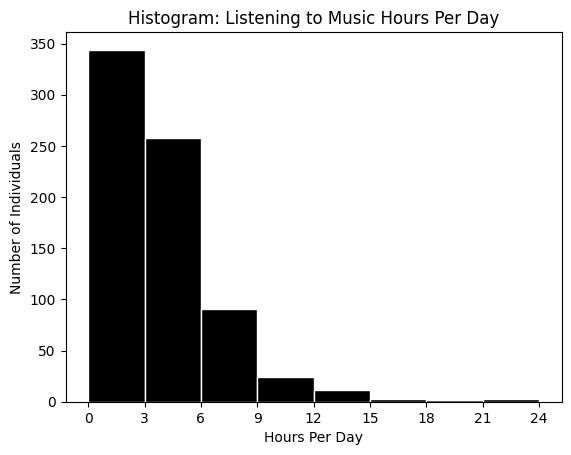

In [324]:
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
plt.hist(df['Hours per day'], color="#000000", edgecolor = "#ffffff", bins = bins)

plt.xlabel("Hours Per Day")
plt.ylabel("Number of Individuals")
plt.xticks(bins)
plt.title("Histogram: Listening to Music Hours Per Day")
plt.show()

**Histogram:**

> The variable shown in the histogram is the "Hours per day" column which is the number of hours individuals spend in a day listening to music

> Used for visualizing and analyzing the amount of people who listen to music for a certain ranges of hours

> Most of the people listen to music for 0-3 hours

> Some people have even claimed to listen to music for 24 hours per day which can be called as outlier

> **Skewness:** From the histogram we can see that the data is right skewed as the tail of the histogram is on the right.

> **Mean > Median > Mode**

> Modality Distribution: The Modality distribution of the data is unimodal as there is only one signigicant peak in the histogram

In [327]:
print('Mean:', df['Hours per day'].mean()) 
print('Median:', df['Hours per day'].median()) 
print('Mode:', df['Hours per day'].mode())

Mean: 3.5727581521739133
Median: 3.0
Mode: 0    2.0
Name: Hours per day, dtype: float64


#### Pie-Chart

In [340]:
streaming_services_value_count = df['Primary streaming service'].value_counts()
streaming_services_value_count

Primary streaming service
Spotify                              459
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50
Pandora                               11
Name: count, dtype: int64

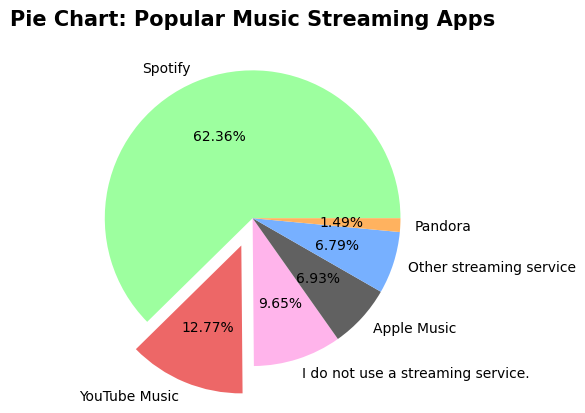

In [380]:
pie_labels =  ['Spotify', 'YouTube Music', 'I do not use a streaming service.', 'Apple Music', 'Other streaming service', 'Pandora']
plt.pie(streaming_services_value_count, labels = pie_labels, autopct = "%.2f%%", explode = [0, 0.2, 0, 0, 0, 0], colors=["#9DFF9F", "#ED6767", "#FFB4EB", "#616161", "#77B0FFFF", "#ffb25f"])

plt.title("Pie Chart: Popular Music Streaming Apps", fontdict = {"fontsize": '15', 'fontweight': 'bold'})

plt.show()

**Pie Chart**

> From the Pie Chart the percentages of the use of different streaming services (music) of the people who took the survery can be seen.

> The most popular music streaming app is Spotify which is dominating the market with quite a big margin.

> YouTube music and Apple music follow Spotify and Pandora is used my extremely few people

> More than 9 percent of people do not use a streaming service and more than 6 percent of people use other streaming services apart from the mentioned ones

#### Box-Plot

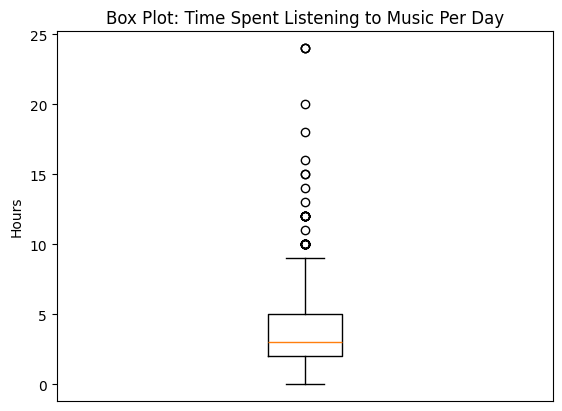

In [401]:
plt.boxplot(df['Hours per day'])

plt.title("Box Plot: Time Spent Listening to Music Per Day")
plt.xticks([])
plt.ylabel("Hours")
plt.show()

**Box Plot**

> Used for identifying the outliers and the IQR of the data.

> Q1 => 2 approx

> Median or Q2 => 3.5 approx

> Q3 => 5 approx

> The outliers start from around 10 hours to 24 hours (About 10 outliers present)

#### Bar-Plot

In [406]:
bar_points = df['Primary streaming service'].value_counts()
bar_points

Primary streaming service
Spotify                              459
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50
Pandora                               11
Name: count, dtype: int64

In [411]:
bar_points.index

Index(['Spotify', 'YouTube Music', 'I do not use a streaming service.',
       'Apple Music', 'Other streaming service', 'Pandora'],
      dtype='str', name='Primary streaming service')

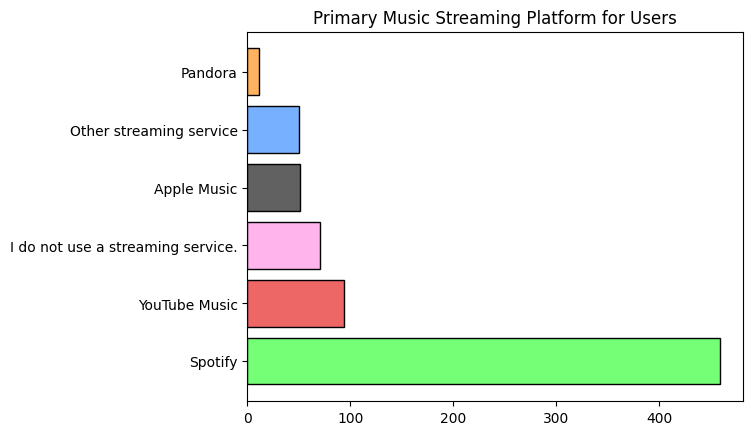

In [420]:
colors=["#74FF77", "#ED6767", "#FFB4EB", "#616161", "#77B0FFFF", "#ffb25f"]

plt.barh(bar_points.index, bar_points, color = colors, edgecolor = "#000000")

plt.title("Primary Music Streaming Platform for Users")

plt.show()

**Bar-Chart:**

> It is used for showing the modality distribution of Primary Music Streaming Platform of users.

> ***Modality Distribution:*** There is a unimodal distribution of data here as there is only one peak in the bar chart that is of Spotify app.

> YouTube Music and Apple Music Follow Spotify and Pandora is used by only a few individuals


### Bivariate Analysis

#### Numerical and Catagorial Dataframe Differentiated

In [422]:
numeric_df = df.select_dtypes(include = 'number')
categorical_df = df.select_dtypes(exclude = 'number')

In [424]:
numeric_df.head(2)

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
0,18.0,3.0,156.0,3.0,0.0,1.0,0.0
1,63.0,1.5,119.0,7.0,2.0,2.0,1.0


In [425]:
categorical_df.head(2)

,Timestamp,Primary streaming service,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,Frequency [Classical],Frequency [Country],...,Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Music effects,Permissions
0,8/27/2022 19:29:02,Spotify,Yes,Yes,Yes,Latin,Yes,Yes,Rarely,Never,...,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,No effect,I understand.
1,8/27/2022 19:57:31,Pandora,Yes,No,No,Rock,Yes,No,Sometimes,Never,...,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,No effect,I understand.


#### Use of Pairplot

In [427]:
numeric_df

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
0,18.0,3.0,156.0,3.0,0.0,1.0,0.0
1,63.0,1.5,119.0,7.0,2.0,2.0,1.0
2,18.0,4.0,132.0,7.0,7.0,10.0,2.0
3,61.0,2.5,84.0,9.0,7.0,3.0,3.0
4,18.0,4.0,107.0,7.0,2.0,5.0,9.0
...,...,...,...,...,...,...,...
731,17.0,2.0,120.0,7.0,6.0,0.0,9.0
732,18.0,1.0,160.0,3.0,2.0,2.0,5.0
733,19.0,6.0,120.0,2.0,2.0,2.0,2.0
734,19.0,5.0,170.0,2.0,3.0,2.0,1.0


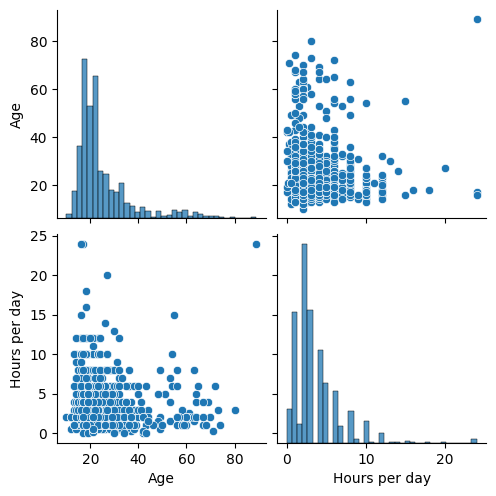

In [430]:
sns.pairplot(data = numeric_df, vars = ['Age', 'Hours per day'])

plt.show()

**Pairplot:**

> Major Concentration of Data points can be seen in the lower age range with the highest hours per day of listening to music also in the lower age range

> As the age range increase, the concentration of the data points decrease which shows majority of survey takers are younger people

> It can be concluded that younger people spend time listening to music more than the older generation.

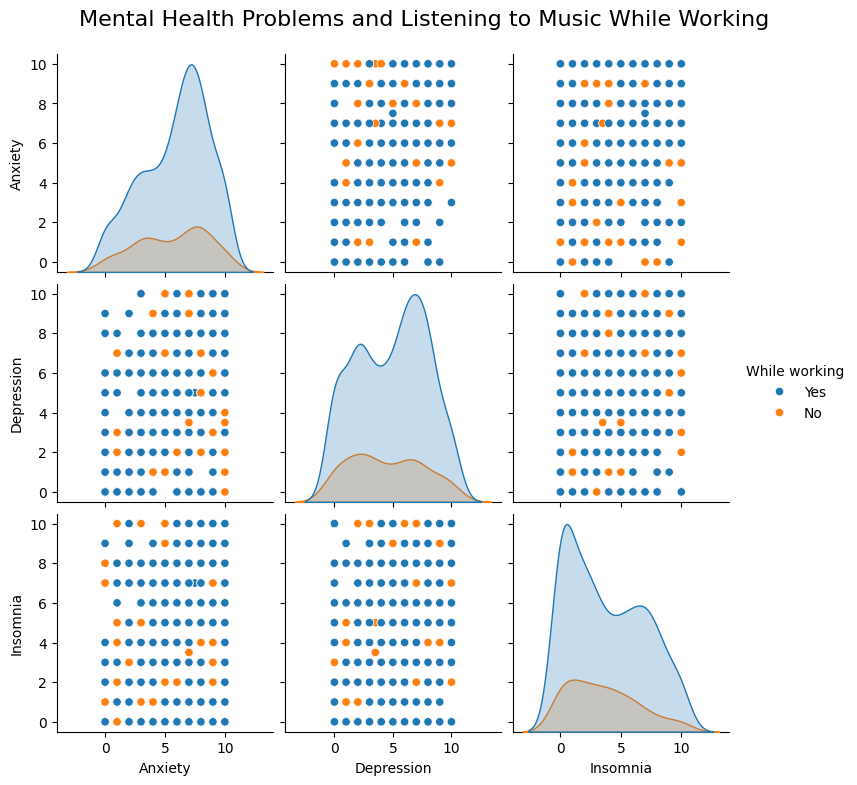

In [444]:
sns.pairplot(df[['Anxiety', 'Depression', "Insomnia", 'While working']], hue = 'While working', kind = 'scatter')

plt.suptitle("Mental Health Problems and Listening to Music While Working", fontsize = 16, ha = 'center', va = 'top', y = 1.04) #ha => horizontal alignment, va => vertical alignment, y => y-axis

plt.show()

**Pairplot:**

> Most of the people suffering from Mental Health Issues listen to music while working which may indicate that the majority of the people.

> The people who are suffering for major depression and anxiety show tendency to listen to music less than who suffer lower levels of depression.

> Where as individuals who suffer from severe insomnia mostly listen to music while working

#### Scatter Plot

<Axes: xlabel='Age', ylabel='Fav genre'>

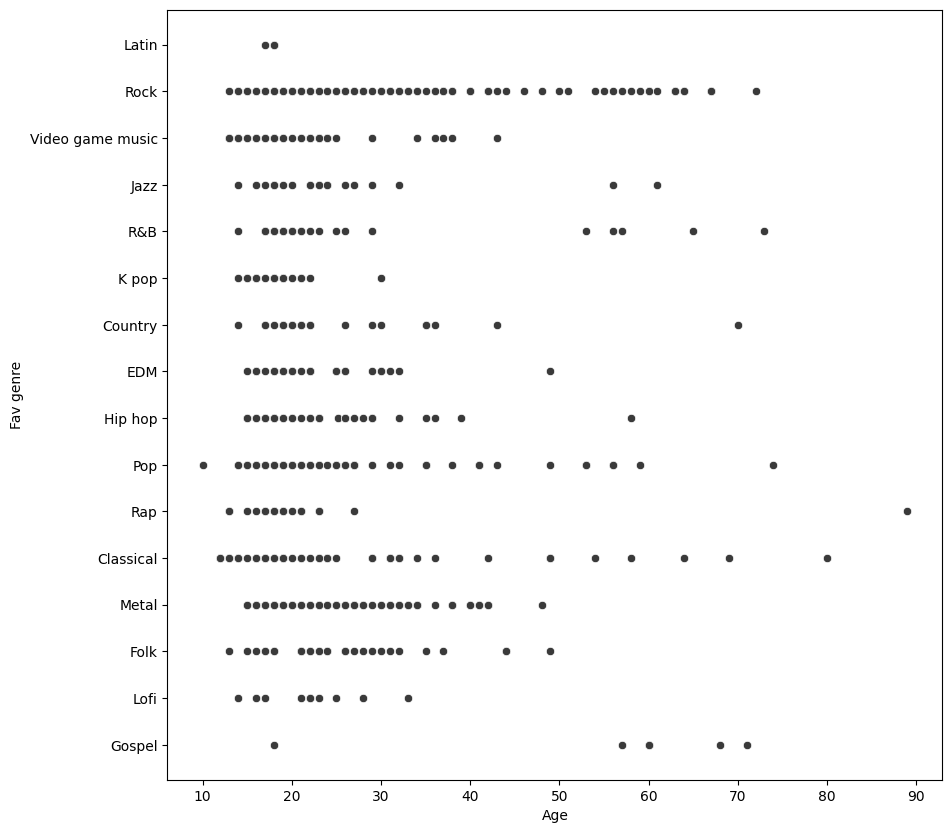

In [458]:
plt.figure(figsize = (10, 10))

sns.scatterplot(data = df, x = 'Age', y = 'Fav genre', color = "#3A3A3A")

**Scatterplot:**

> Majority of youngsters and adults enjoy 'Rock' music.

> Video game music is famous among people of age 10 - 30

> Least consumed music genere is Gospel

> Other Popular Genre: Metal and Pop

> ***One 90 year old's fav genre is Rap***

#### Heatmap

In [460]:
numerical_heatmap = numeric_df.corr()
numerical_heatmap

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
Age,1.000000,-0.044636,-0.048777,-0.176508,-0.121534,0.006907,-0.129905
Hours per day,-0.044636,1.000000,0.047479,0.049319,0.110527,0.141821,0.118729
BPM,-0.048777,0.047479,1.000000,-0.012695,0.052302,0.044868,-0.003949
Anxiety,-0.176508,0.049319,-0.012695,1.000000,0.519969,0.292669,0.348350
Depression,-0.121534,0.110527,0.052302,0.519969,1.000000,0.378996,0.196988
Insomnia,0.006907,0.141821,0.044868,0.292669,0.378996,1.000000,0.226354
OCD,-0.129905,0.118729,-0.003949,0.348350,0.196988,0.226354,1.000000


<Axes: >

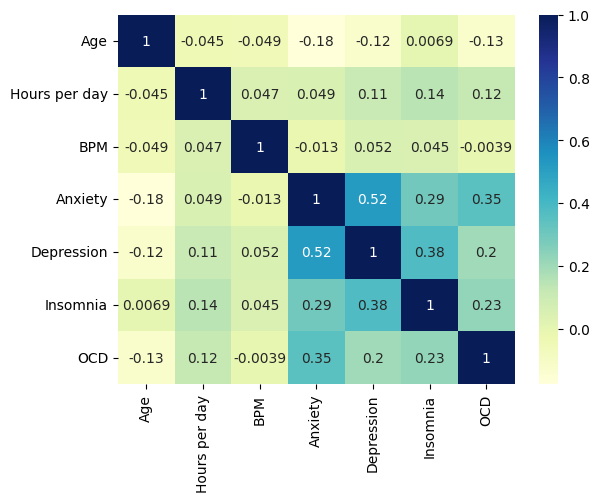

In [462]:
sns.heatmap(numerical_heatmap, annot = True, cmap = "YlGnBu")

In [474]:
for i in df: 
    if len(df[i].unique()) == 2 and set(df[i].unique()) == {'Yes', 'No'}:
        print(i)


While working
Instrumentalist
Composer
Exploratory
Foreign languages


In [ ]:
heat_df = df.copy()

def label_encoder(conn):
    if conn == 'Yes':
        return 1
    elif conn == 'No':
        return 0

yn_columns = ['While working', 'Instrumentalist', 'Composer', 'Exploratory', 'Foreign languages']
for col in yn_columns:
    heat_df[col] = heat_df[col].map(label_encoder)

heat_df.head(2)

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,1,1,1,Latin,1,1,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,No effect,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,1,0,0,Rock,1,0,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,No effect,I understand.


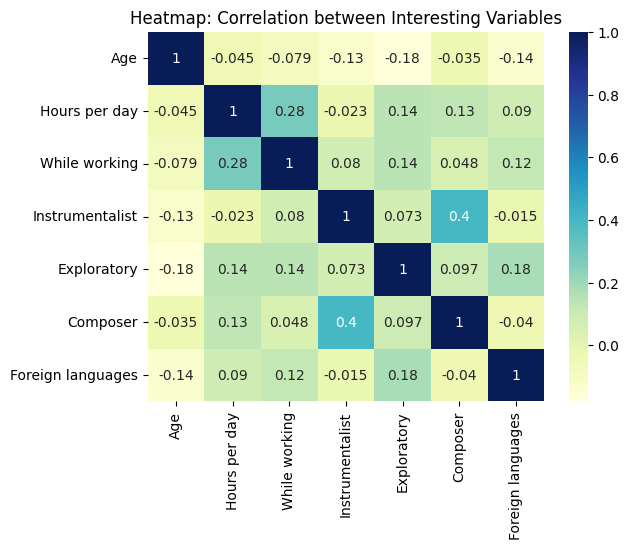

In [481]:
map_heat = heat_df[['Age', 'Hours per day', 'While working', 'Instrumentalist','Exploratory', 'Composer', 'Foreign languages']]
plt.title("Heatmap: Correlation between Interesting Variables")
sns.heatmap(map_heat.corr(), cmap = "YlGnBu", annot = True)
plt.show()

**Heatmap**

> Correlation Range => -1 to 1

> Stronger +ve Correlation can be seen between composer and instrumentalist which shows that a person is more likely to be a instrumentalist if he/she is a composer or vice-versa. 

> Another relatively stronger correlation can be seen between While working and Hours per day which shows that the people show listen to music more also listen it while working which is obvious

> Positive correlation can also be noticed between people who explore new music and people who listen to foreign languages.

#### Fav Genre and Mental Health (Bar Plot)

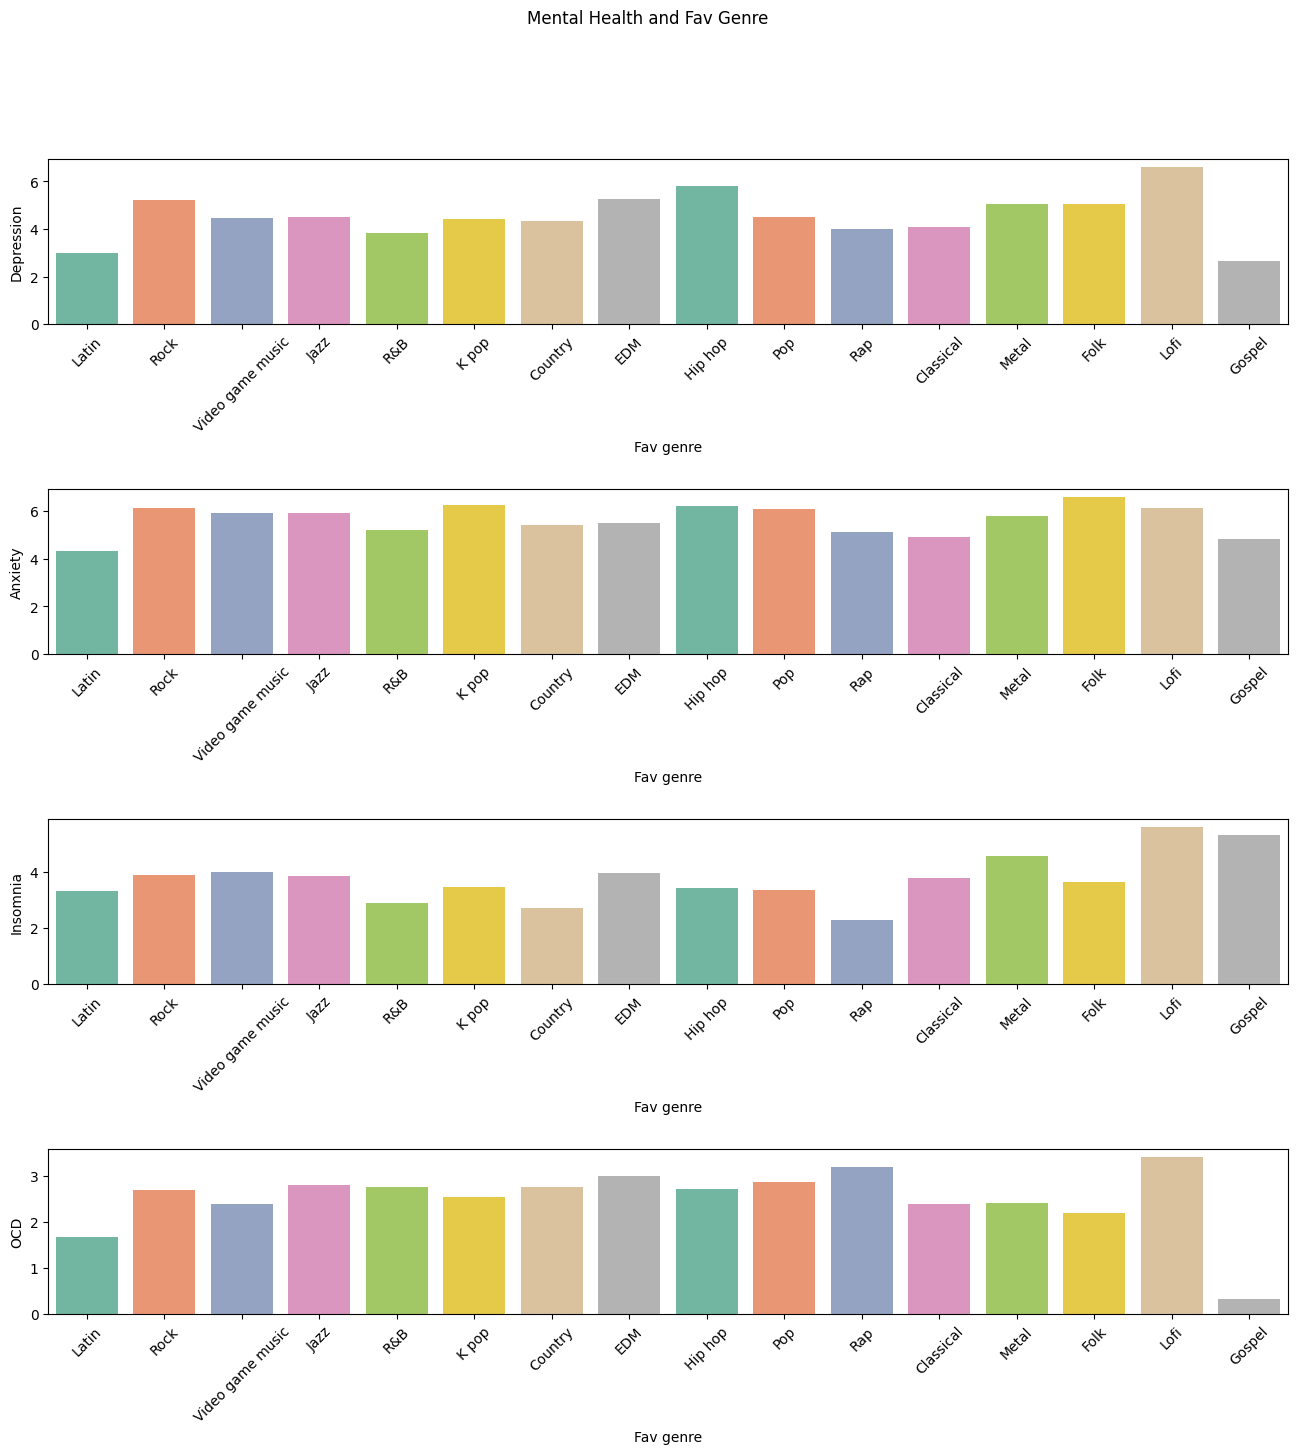

In [ ]:
plt.figure(figsize=(16, 15))

plt.suptitle("Mental Health and Fav Genre")
plt.subplot(4, 1, 1) #(4 rows, 1 column, 1 Position)
sns.barplot(data = df, x = 'Fav genre', y = "Depression", errorbar = None, hue = 'Fav genre', palette='Set2')
plt.xticks(rotation=45)

plt.subplot(4, 1, 2) #(4 rows, 1 column, 2 Position)
sns.barplot(data = df, x = 'Fav genre', y = "Anxiety", errorbar = None, hue = 'Fav genre', palette='Set2')
plt.xticks(rotation=45)

plt.subplot(4, 1, 3) #(4 rows, 1 column, 3 Position)
sns.barplot(data = df, x = 'Fav genre', y = "Insomnia", errorbar = None, hue = 'Fav genre', palette='Set2')
plt.xticks(rotation=45)

plt.subplot(4, 1, 4) #(4 rows, 1 column, 4 Position)
sns.barplot(data = df, x = 'Fav genre', y = "OCD", errorbar = None, hue = 'Fav genre', palette='Set2')
plt.xticks(rotation=45)

plt.subplots_adjust(hspace = 1)

plt.show()

**Observation:**

> Lofi music is the most listened music among people with drepression, insomnia and OCD

> Folk music is mostly listened by people with anxiety

> Gospel music is listened by individuals with insomnia